# Проект "Определение возраста покупателей" (курс "Компьютерное зрение")

## Постановка задачи

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
- Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- Контролировать добросовестность кассиров при продаже алкоголя.

**Постройте модель, которая по фотографии определит приблизительный возраст человека**. 

В вашем распоряжении набор фотографий людей с указанием возраста.

### Критерии успеха
- Постройте и обучите свёрточную нейронную сеть на датасете с фотографиями людей. Добейтесь значения **MAE на тестовой выборке не больше 8**.
- В [статье о датасете](https://inria.hal.science/hal-01677892/document),  с которым вы работаете, значение MAE равно 5.4 — **если вы получите MAE меньше 7, это будет отличный результат**!

<div class="alert alert-secondary" style="background-color:#D9EEE1;color:black;">

### Описание данных

В папке path содержится CSV-файл labels.csv с двумя колонками file_name и real_age и папка с изображениями /final_files.

- **Целевой признак:**
    - real_age (задача регрессии)


## Импорт библиотек

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, \
                                    Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Исследовательский анализ данных

In [2]:
df = pd.read_csv("/datasets/faces/labels.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [3]:
df.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


В датасете 7591 элементов.

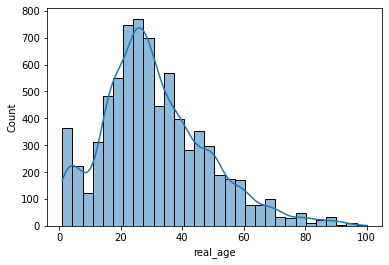

In [8]:
sns.histplot(
    data=df,
    x='real_age',
    multiple='dodge',
    bins=30,
    kde=True);

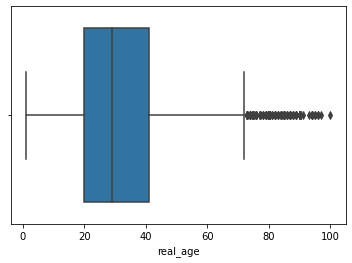

In [15]:
sns.boxplot(data=df, orient="h", x = 'real_age');

In [17]:
df['real_age'].describe()

count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64

- Распределение похоже на нормальное со сдвигом в сторону 25 лет
- Медианный возраст 29 лет, минимальный - 1 год, максимальный 100

посмотрим на троих людей из каждого 10-летнего бина:

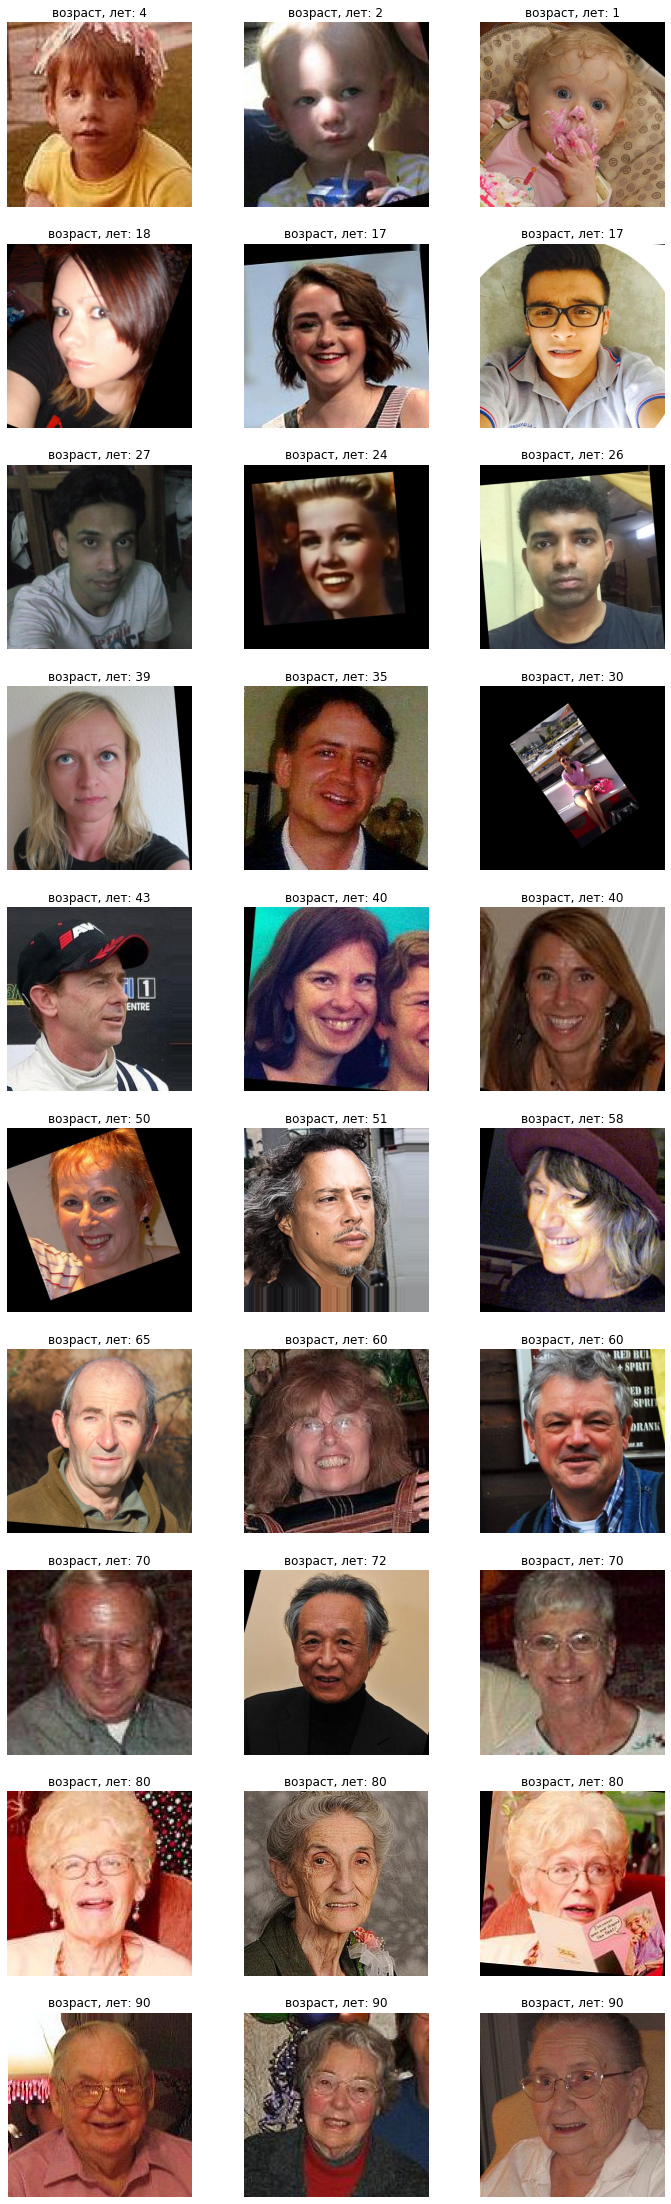

In [73]:
N = 10
M=3
fig, axes = plt.subplots(N, M, figsize=(12, 4 * N))

for i in range (N):
    q = df.loc[(df['real_age'] >= i*10) & (df['real_age'] < (i+1)*10)].head(M)
    for j in range(q.shape[0]):
        image = Image.open(f'/datasets/faces/final_files/{q.iloc[j]["file_name"]}')
        ax = axes[i][j]
        ax.imshow(image)
        ax.set_title(f'возраст, лет: {q.iloc[j]["real_age"]}') 
        ax.axis('off')

Вывод: разметка выглядит адекватно.

## Обучение модели

### Код дообучения ResNet50

In [ ]:
def load_train(path):
    df = pd.read_csv(f'{path}/labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25)    
    train_datagen_flow = datagen.flow_from_dataframe(
            df, directory=f'{path}final_files/',
            x_col='file_name', y_col='real_age',
            target_size=(150, 150),
            batch_size=16,
            class_mode='raw',
            subset='training',
            seed=12345)
    return train_datagen_flow

def load_test(path):
    df = pd.read_csv(f'{path}/labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25)    
    val_datagen_flow = datagen.flow_from_dataframe(
        df, directory=f'{path}final_files/',
        x_col='file_name', y_col='real_age',
        target_size=(150, 150),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=12345)
    return val_datagen_flow

def create_model(input_shape):

    backbone = ResNet50(input_shape=input_shape,#(150, 150, 3),
                    #weights='/datasets/keras_models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
                    weights='imagenet', 
                    include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(20, activation='relu'))

    optimizer = Adam(lr=0.0001)
    model.compile(optimizer=optimizer, loss='mean_squared_error', 
            metrics=['mae']) 

    return model

def train_model(model, train_data, test_data, batch_size=None, epochs=5,
                steps_per_epoch=None, validation_steps=None):

    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)
    return model 

### Результаты обучения

## Отчёт и выводы

- В соответствии с поставленной задачей (см. первый раздел)
    - была проведён разведочный анализ данных:
        - Изучены по 3 фотографии каждого десятелетия - разметка выглядит адекватно.
        - Распределение возраста похоже на нормальное со сдвигом в сторону 25 лет
        - Медианный возраст 29 лет, минимальный - 1 год, максимальный 100
    - на основе ResNet50 была переобучена голова на предоставленном [датасете](https://inria.hal.science/hal-01677892/document), предсказывающая возраст человека с фотографии
        - качество предсказания: **Test MAE: 6.5207**
        - это удовлетворяет заданный критерий качества: **MAE на тестовой выборке не больше 8**